[DEBUG] AFM: common pairs so far = 70
[DEBUG] AF3: common pairs so far = 64
[INFO] Final common successful pairs: 64
[INFO] AFM: n_pairs = 64, Precision = 0.403, Recall = 0.328, mean_score = 0.371, zero-recall_frac = 0.156
[INFO] AF3: n_pairs = 64, Precision = 0.310, Recall = 0.472, mean_score = 0.388, zero-recall_frac = 0.047
[INFO] AlphaFold-Multimer: n_pairs=64, zero-recall_frac=0.156
[INFO] AlphaFold3: n_pairs=64, zero-recall_frac=0.047
[INFO] AlphaFold-Multimer micro P/R: (0.403, 0.328)
[INFO] AlphaFold3 micro P/R: (0.310, 0.472)


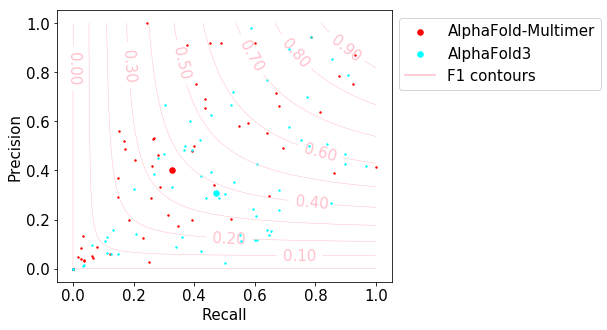

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

plt.style.use("seaborn-pastel")

# ============================================================
# Config
# ============================================================
WKDIR = "FigS1D/"
OUTPUT_DIR = "FigS1D"

# Methods and corresponding benchmark files
FILES = {
    # AlphaFold-Multimer (v2)
    "AFM": "interface_all_interspecies_AFM_ESM_all_score_pdockq_newBenchmark_with_info_AFMv2.txt",
    # AlphaFold3
    "AF3": "interface_all_interspecies_AFM_ESM_all_score_pdockq_newBenchmark_with_info_AFv3.txt",
}

# Date cutoffs per method (strings like 'DD-MMM-YY')
COMMON_COND = True
if COMMON_COND:
    PAT_COMM = "common"
    DATE_CUTOFF = {
        "AFM": "30-SEP-21",
        "AF3": "30-SEP-21",
    }
else:
    PAT_COMM = "specific"
    DATE_CUTOFF = {
        "AFM": "30-APR-18",
        "AF3": "30-SEP-21",
    }

SCORE_THR = (0.0, 1.0)
PLDDT_THR = (50.0, 100.0)

TIME_MODE = 0  # 0: all data; 1: Date_after_train only
ORG_MODE = 0   # 0: all organisms; 1: viruses only; 2: bacteria only

EPS = 1e-5  # numerical stability


# ============================================================
# Helpers
# ============================================================

# Map 3-letter month abbreviations to month numbers
DATE_ABBREV_TO_NUM = {
    "JAN": 1,
    "FEB": 2,
    "MAR": 3,
    "APR": 4,
    "MAY": 5,
    "JUN": 6,
    "JUL": 7,
    "AUG": 8,
    "SEP": 9,
    "OCT": 10,
    "NOV": 11,
    "DEC": 12,
}


def _tokens_to_ymd(tokens):
    """
    Convert ['DD','MON','YY'] or ['DD','MM','YY'] tokens to (YYYY, MM, DD),
    using the same 2-digit year logic as the original code:
      - years > 35 -> 19YY
      - years <= 35 -> 20YY
    """
    day_str, mon_str, year_str = tokens

    # Month can be 'APR' or '4'
    try:
        month = DATE_ABBREV_TO_NUM[mon_str.upper()]
    except Exception:
        month = int(mon_str)

    day = int(day_str)
    year = int(year_str)
    if year > 35:
        year += 1900
    else:
        year += 2000

    return year, month, day


def before_date(date1, date2=None):
    """
    Compare two dates given as ['DD','MON','YY'] tokens.

    NOTE (matching original behavior):
      - date1 and date2 are *token lists*, e.g. ['30','SEP','21'].
      - Returns True if date2 is *strictly later* than date1:
            (Y2,M2,D2) > (Y1,M1,D1)
        This is the same as:
            (year2*10000 + month2*100 + day2) > (year1*10000 + month1*100 + day1)
    """
    if date2 is None:
        # Original default ['30','APR','18'] is never used in your current calls,
        # but we keep the same default for compatibility.
        date2 = ["30", "APR", "18"]

    y1, m1, d1 = _tokens_to_ymd(date1)
    y2, m2, d2 = _tokens_to_ymd(date2)

    # Exact same comparison as in the original code
    return (y2 * 10000 + m2 * 100 + d2) > (y1 * 10000 + m1 * 100 + d1)


def read_date(fname, mode=0):
    """
    Read a PDB-style date substring from a file.

    - If the file exists, read the first line, take characters [50:60],
      strip, then split by '-'.
    - If the file does not exist, default to ['01','JAN','01'].
    - If mode == 1, reorder the tokens exactly as in the original code.
    """
    if os.path.exists(fname):
        with open(fname, "r") as f:
            first_line = f.readline()
        # Keep the same fixed-width slice and parsing
        date = [token for token in first_line[50:60].strip().split("-")]
    else:
        date = ["01", "JAN", "01"]

    if mode == 1:
        # Original behavior: reorder tokens
        # (this looks odd but is preserved exactly)
        date = [date[2], date[1], date[0][2:]]

    return date

def convert_ires_string_to_list(ires_str: str):
    """
    Expand interface residue string like '[10,12-15,20]' -> [10,12,13,14,15,20].
    """
    s = ires_str.replace("[", "").replace("]", "")
    if s.strip() == "":
        return []
    segments = s.split(",")
    nested = [
        list(range(int(seg.split("-")[0]), int(seg.split("-")[1]) + 1))
        if "-" in seg
        else [int(seg)]
        for seg in segments
    ]
    return [pos for sub in nested for pos in sub]


def calc_res(IresA, IresB, pIresA, pIresB, sel_pt: int = 0):
    """
    Per-pair precision/recall, identical to original logic.
    sel_pt=0: both chains; 1: chain A; 2: chain B.
    """
    i1 = len(set(pIresA) & set(IresA))
    i2 = len(set(pIresB) & set(IresB))

    if sel_pt == 0:
        pre = round((i1 + i2) / (len(pIresA) + len(pIresB) + EPS), 3)
        rec = round((i1 + i2) / (len(IresA) + len(IresB) + EPS), 3)
    elif sel_pt == 1:
        pre = round(i1 / (len(pIresA) + EPS), 3)
        rec = round(i1 / (len(IresA) + EPS), 3)
    elif sel_pt == 2:
        pre = round(i2 / (len(pIresB) + EPS), 3)
        rec = round(i2 / (len(IresB) + EPS), 3)
    else:
        raise ValueError("sel_pt must be 0, 1, or 2.")
    return pre, rec


def calc_res_set(IresA_all, IresB_all, pIresA_all, pIresB_all, sel_pt: int = 0):
    """
    Global (micro) precision/recall over all residues, same as original.
    """
    i1 = len(set(pIresA_all) & set(IresA_all))
    i2 = len(set(pIresB_all) & set(IresB_all))

    if sel_pt == 0:
        pre = round((i1 + i2) / (len(pIresA_all) + len(pIresB_all) + EPS), 3)
        rec = round((i1 + i2) / (len(IresA_all) + len(IresB_all) + EPS), 3)
    elif sel_pt == 1:
        pre = round(i1 / (len(pIresA_all) + EPS), 3)
        rec = round(i1 / (len(IresA_all) + EPS), 3)
    elif sel_pt == 2:
        pre = round(i2 / (len(pIresB_all) + EPS), 3)
        rec = round(i2 / (len(IresB_all) + EPS), 3)
    else:
        raise ValueError("sel_pt must be 0, 1, or 2.")
    return pre, rec


def select_subset(v2h_df: pd.DataFrame, method_key: str) -> pd.DataFrame:
    """
    Apply score, date and organism filters.
    Uses external before_date(cutoff_tokens, date_tokens).
    """
    score_min, score_max = SCORE_THR
    idx_common = v2h_df["score"] >= 0  # same as original

    cutoff_tokens = DATE_CUTOFF[method_key].split("-")
    v2h_df = v2h_df.copy()
    v2h_df["TempBefore"] = v2h_df["Oldest_Date"].apply(
        lambda x: before_date(cutoff_tokens, x.split("-"))
    )

    if TIME_MODE == 1:
        base_mask = (
            idx_common
            & (v2h_df["score"] >= score_min)
            & (v2h_df["score"] <= score_max)
            & v2h_df["TempBefore"]
            & v2h_df["Date_after_train"]
        )
    else:
        base_mask = (
            idx_common
            & (v2h_df["score"] >= score_min)
            & (v2h_df["score"] <= score_max)
            & v2h_df["TempBefore"]
        )

    if ORG_MODE == 0:
        mask = base_mask
    elif ORG_MODE == 1:
        mask = base_mask & (
            (v2h_df["DomainA"] == "Viruses") | (v2h_df["DomainB"] == "Viruses")
        )
    elif ORG_MODE == 2:
        mask = base_mask & (
            (v2h_df["DomainA"] != "Viruses") & (v2h_df["DomainB"] != "Viruses")
        )
    else:
        raise ValueError("ORG_MODE must be 0, 1, or 2.")

    return v2h_df.loc[mask]


def compute_successful_pairs_for_method(v2h_sel: pd.DataFrame) -> set:
    """
    Pairs where AFM-style structural criteria give at least one interface residue
    on both chains under the chosen pLDDT threshold.
    """
    plddt_thr_min, plddt_thr_max = PLDDT_THR
    successful_pairs = set()

    cols = [
        "UniProtA",
        "UniProtB",
        "TaxIDA",
        "TaxIDB",
        "UniProtIresA",
        "UniProtIresB",
        "ProtA_rSASA",
        "ProtB_rSASA",
        "ProtA_dSASA",
        "ProtB_dSASA",
        "ProtA_res_range",
        "ProtB_res_range",
        "ProtA_ires_plddt",
        "ProtB_ires_plddt",
    ]

    for (
        UniProtA,
        UniProtB,
        TaxIDA,
        TaxIDB,
        UniProtIresA,
        UniProtIresB,
        ProtA_rSASA,
        ProtB_rSASA,
        ProtA_dSASA,
        ProtB_dSASA,
        ProtA_res_range,
        ProtB_res_range,
        ProtA_ires_plddt,
        ProtB_ires_plddt,
    ) in v2h_sel[cols].values:
        pair_id = f"{UniProtA}_{UniProtB}"

        # AFM-style interface definition
        res_rangeA = np.array(
            [int(ele) for ele in ProtA_res_range.replace("\n", "")[1:-1].split(",")]
        )
        res_rangeB = np.array(
            [int(ele) for ele in ProtB_res_range.replace("\n", "")[1:-1].split(",")]
        )
        dSASAA = np.array([float(ele) for ele in ProtA_dSASA.split(",")])
        dSASAB = np.array([float(ele) for ele in ProtB_dSASA.split(",")])
        rSASAA = np.array([float(ele) for ele in ProtA_rSASA.split(",")])
        rSASAB = np.array([float(ele) for ele in ProtB_rSASA.split(",")])
        ires_plddtA = np.array(
            [float(ele) for ele in ProtA_ires_plddt.replace("\n", "").split(",")]
        )
        ires_plddtB = np.array(
            [float(ele) for ele in ProtB_ires_plddt.replace("\n", "").split(",")]
        )

        pIresA = res_rangeA[
            (dSASAA >= 1.0)
            & (rSASAA >= 15.0)
            & (ires_plddtA > plddt_thr_min)
            & (ires_plddtA <= plddt_thr_max)
        ]
        pIresB = res_rangeB[
            (dSASAB >= 1.0)
            & (rSASAB >= 15.0)
            & (ires_plddtB > plddt_thr_min)
            & (ires_plddtB <= plddt_thr_max)
        ]

        if len(pIresA) * len(pIresB) > 0:
            successful_pairs.add(pair_id)

    return successful_pairs


def compute_common_successful_pairs() -> set:
    """
    Intersection of 'successful pairs' across all methods
    (same as original final_common_list).
    """
    final_common = None
    for method_key, filename in FILES.items():
        v2h = pd.read_csv(f"{WKDIR}{filename}", sep="\t")
        v2h_sel = select_subset(v2h, method_key)
        method_pairs = compute_successful_pairs_for_method(v2h_sel)

        if final_common is None:
            final_common = method_pairs
        else:
            final_common &= method_pairs

        print(f"[DEBUG] {method_key}: common pairs so far = {len(final_common)}")

    return final_common if final_common is not None else set()


def compute_metrics_for_method(method_key: str, filename: str, common_pairs: set):
    """
    Per-method metrics restricted to common successful pairs.
    From my view: this enforces a fair AFM vs AF3 comparison.
    """
    v2h = pd.read_csv(f"{WKDIR}{filename}", sep="\t")
    v2h_sel = select_subset(v2h, method_key)

    plddt_thr_min, plddt_thr_max = PLDDT_THR

    IresA_all, IresB_all = [], []
    pIresA_all, pIresB_all = [], []
    pre_list, rec_list = [], []

    cols = [
        "UniProtA",
        "UniProtB",
        "TaxIDA",
        "TaxIDB",
        "UniProtIresA",
        "UniProtIresB",
        "ProtA_rSASA",
        "ProtB_rSASA",
        "ProtA_dSASA",
        "ProtB_dSASA",
        "ProtA_res_range",
        "ProtB_res_range",
        "ProtA_ires_plddt",
        "ProtB_ires_plddt",
    ]

    sel_pt = 0  # both chains (allProts), like original

    for (
        UniProtA,
        UniProtB,
        TaxIDA,
        TaxIDB,
        UniProtIresA,
        UniProtIresB,
        ProtA_rSASA,
        ProtB_rSASA,
        ProtA_dSASA,
        ProtB_dSASA,
        ProtA_res_range,
        ProtB_res_range,
        ProtA_ires_plddt,
        ProtB_ires_plddt,
    ) in v2h_sel[cols].values:
        pair_id = f"{UniProtA}_{UniProtB}"

        # AFM-style pIres (same as above)
        res_rangeA = np.array(
            [int(ele) for ele in ProtA_res_range.replace("\n", "")[1:-1].split(",")]
        )
        res_rangeB = np.array(
            [int(ele) for ele in ProtB_res_range.replace("\n", "")[1:-1].split(",")]
        )
        dSASAA = np.array([float(ele) for ele in ProtA_dSASA.split(",")])
        dSASAB = np.array([float(ele) for ele in ProtB_dSASA.split(",")])
        rSASAA = np.array([float(ele) for ele in ProtA_rSASA.split(",")])
        rSASAB = np.array([float(ele) for ele in ProtB_rSASA.split(",")])
        ires_plddtA = np.array(
            [float(ele) for ele in ProtA_ires_plddt.replace("\n", "").split(",")]
        )
        ires_plddtB = np.array(
            [float(ele) for ele in ProtB_ires_plddt.replace("\n", "").split(",")]
        )

        pIresA = res_rangeA[
            (dSASAA >= 1.0)
            & (rSASAA >= 15.0)
            & (ires_plddtA > plddt_thr_min)
            & (ires_plddtA <= plddt_thr_max)
        ]
        pIresB = res_rangeB[
            (dSASAB >= 1.0)
            & (rSASAB >= 15.0)
            & (ires_plddtB > plddt_thr_min)
            & (ires_plddtB <= plddt_thr_max)
        ]

        if (len(pIresA) * len(pIresB) <= 0) or (pair_id not in common_pairs):
            continue

        # Truth interface residues (expanded) with consistent encoding
        IresA = convert_ires_string_to_list(UniProtIresA)
        IresB = convert_ires_string_to_list(UniProtIresB)

        IresA_str = [f"{UniProtA}_{UniProtB}_{UniProtA}_{res}" for res in IresA]
        IresB_str = [f"{UniProtA}_{UniProtB}_{UniProtB}_{res}" for res in IresB]
        pIresA_str = [f"{UniProtA}_{UniProtB}_{UniProtA}_{res}" for res in pIresA]
        pIresB_str = [f"{UniProtA}_{UniProtB}_{UniProtB}_{res}" for res in pIresB]

        IresA_all += IresA_str
        IresB_all += IresB_str
        pIresA_all += pIresA_str
        pIresB_all += pIresB_str

        pre, rec = calc_res(IresA_str, IresB_str, pIresA_str, pIresB_str, sel_pt)
        pre_list.append(pre)
        rec_list.append(rec)

    if len(IresA_all) == 0:
        micro_pre, micro_rec = 0.0, 0.0
    else:
        micro_pre, micro_rec = calc_res_set(
            IresA_all, IresB_all, pIresA_all, pIresB_all, sel_pt
        )

    score_mean = float(v2h_sel["score"].mean()) if len(v2h_sel) > 0 else 0.0
    score_values = v2h_sel["score"].tolist()

    return micro_pre, micro_rec, pre_list, rec_list, score_mean, score_values


# ============================================================
# Main: compute + plot AFM vs AF3
# ============================================================
def main():
    # 1. Common successful pairs across methods
    common_pairs = compute_common_successful_pairs()
    print(f"[INFO] Final common successful pairs: {len(common_pairs)}")

    # 2. Metrics per method
    pre_dic, rec_dic = {}, {}
    pre_ind_dic, rec_ind_dic = {}, {}
    score_dic, score_ind_dic = {}, {}

    for method_key, filename in FILES.items():
        micro_pre, micro_rec, pre_list, rec_list, score_mean, score_values = compute_metrics_for_method(
            method_key, filename, common_pairs
        )
        pre_dic[method_key] = micro_pre
        rec_dic[method_key] = micro_rec
        pre_ind_dic[method_key] = pre_list
        rec_ind_dic[method_key] = rec_list
        score_dic[method_key] = score_mean
        score_ind_dic[method_key] = score_values

    # 3. Hidden stats: #pairs + zero-recall fraction
    for method_key in FILES.keys():
        pre_vals = pre_ind_dic[method_key]
        rec_vals = rec_ind_dic[method_key]
        n_pairs = len(pre_vals)
        frac_zero_rec = (np.array(rec_vals) == 0).sum() / n_pairs if n_pairs > 0 else 0.0

        print(
            f"[INFO] {method_key}: n_pairs = {n_pairs}, "
            f"Precision = {pre_dic[method_key]:.3f}, Recall = {rec_dic[method_key]:.3f}, "
            f"mean_score = {score_dic[method_key]:.3f}, zero-recall_frac = {frac_zero_rec:.3f}"
        )

    # 4. Precision–Recall scatter with F1 contours (Figure)
    method_order = ["AFM", "AF3"]
    labels = ["AlphaFold-Multimer", "AlphaFold3"]

    data_p2 = [pre_ind_dic[m] for m in method_order]  # per-pair precision
    data_r2 = [rec_ind_dic[m] for m in method_order]  # per-pair recall
    data_p = [pre_dic[m] for m in method_order]       # global precision
    data_r = [rec_dic[m] for m in method_order]       # global recall

    fig, ax = plt.subplots(figsize=(6, 5))
    colors = ["red", "cyan"]

    # Per-pair clouds (small dots)
    for i in range(len(data_p2)):
        plt.scatter(
            x=data_r2[i],
            y=data_p2[i],
            color=colors[i],
            marker="o",
            s=2,
        )
        if len(data_r2[i]) > 0:
            frac_zero = (np.array(data_r2[i]) == 0).sum() / len(data_r2[i])
        else:
            frac_zero = 0.0
        print(f"[INFO] {labels[i]}: n_pairs={len(data_r2[i])}, zero-recall_frac={frac_zero:.3f}")

    # Micro-averaged points (large markers)
    for i in range(len(data_p)):
        plt.scatter(
            x=data_r[i],
            y=data_p[i],
            label=labels[i],
            color=colors[i],
            marker="o",
            s=30,
        )
        print(f"[INFO] {labels[i]} micro P/R: ({data_p[i]:.3f}, {data_r[i]:.3f})")

    # F1 contours: F1 = 2PR / (P + R)
    x_grid, y_grid = np.meshgrid(
        np.linspace(0, 1.0, 100), np.linspace(0, 1.0, 100)
    )
    z_grid = 2 * x_grid * y_grid / (x_grid + y_grid + EPS)

    contour_lines = plt.contour(
        x_grid, y_grid, z_grid, levels=10, colors="pink", linewidths=0.5
    )
    plt.clabel(contour_lines, inline=True, fontsize=15, fmt="%1.2f")

    # Legend: methods + F1 proxy
    contour_proxy = plt.Line2D([], [], color="pink", label="F1 contours")
    handles, legend_labels = plt.gca().get_legend_handles_labels()
    handles.append(contour_proxy)
    plt.legend(handles=handles, bbox_to_anchor=(1.0, 1.0), fontsize=15)

    plt.xlabel("Recall", fontsize=15)
    plt.ylabel("Precision", fontsize=15)
    ax.tick_params(labelsize=15)

    fig.savefig(
        f"{OUTPUT_DIR}/FigS1D.svg",
        format="svg",
        bbox_inches="tight",
    )
    plt.show()


if __name__ == "__main__":
    main()
